In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as st
import seaborn as sns

In [3]:
df = pd.read_csv("data/resultats.csv",index_col = "Country Name")

In [4]:
# Remplir les valeurs manquantes en utilisant le coffecient de variance 
for col in df.columns:
    Cv = df[col].std() / df[col].mean()
    if Cv > 0.1:
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mean())

In [5]:
# Creer la matrice de correlation (spearman vs. pearson)
spearman = df.corr(method= "spearman")
pearson = df.corr(method = "pearson")

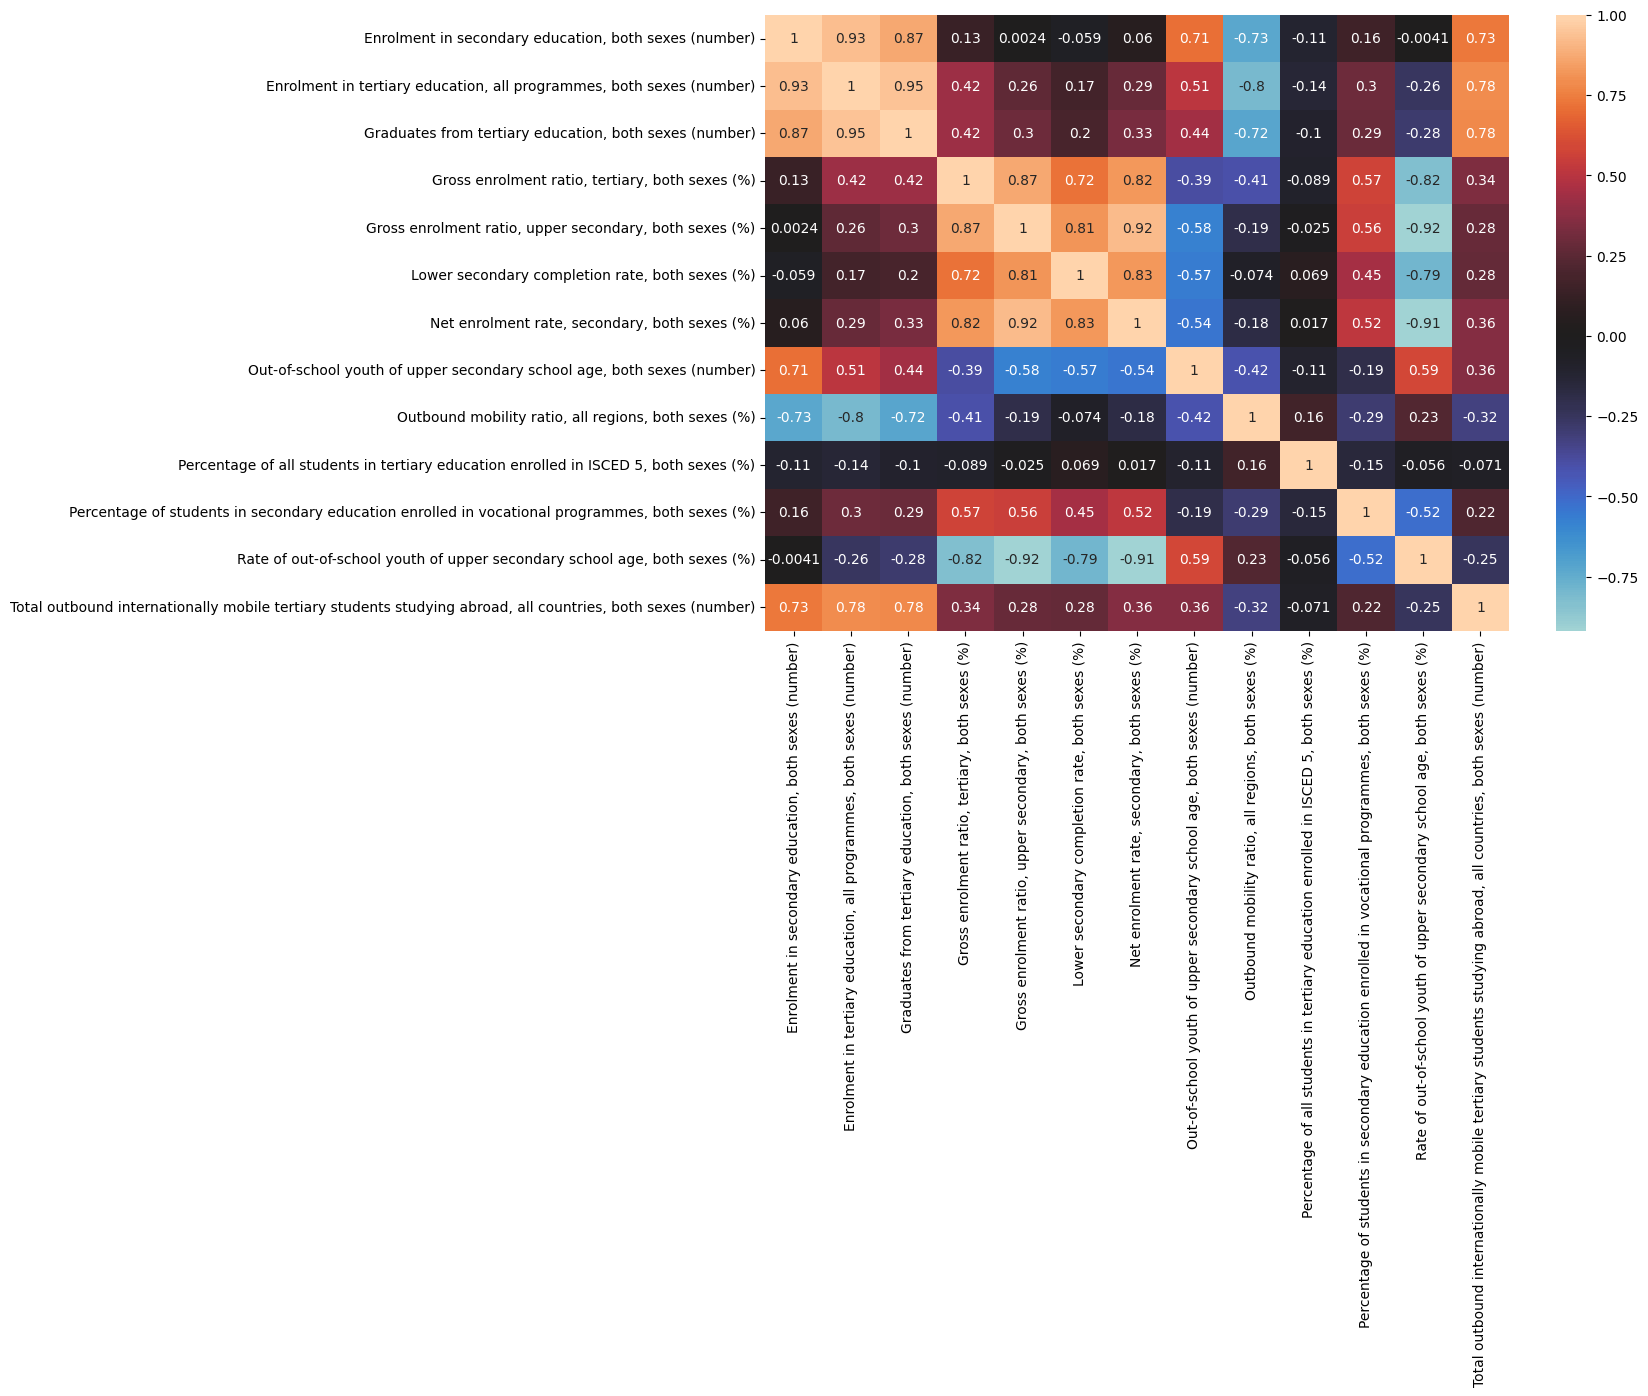

In [6]:
# spearman heatmap
plt.figure(figsize=(12,8))
sns.heatmap(spearman, annot= True, center = 0)
plt.show()

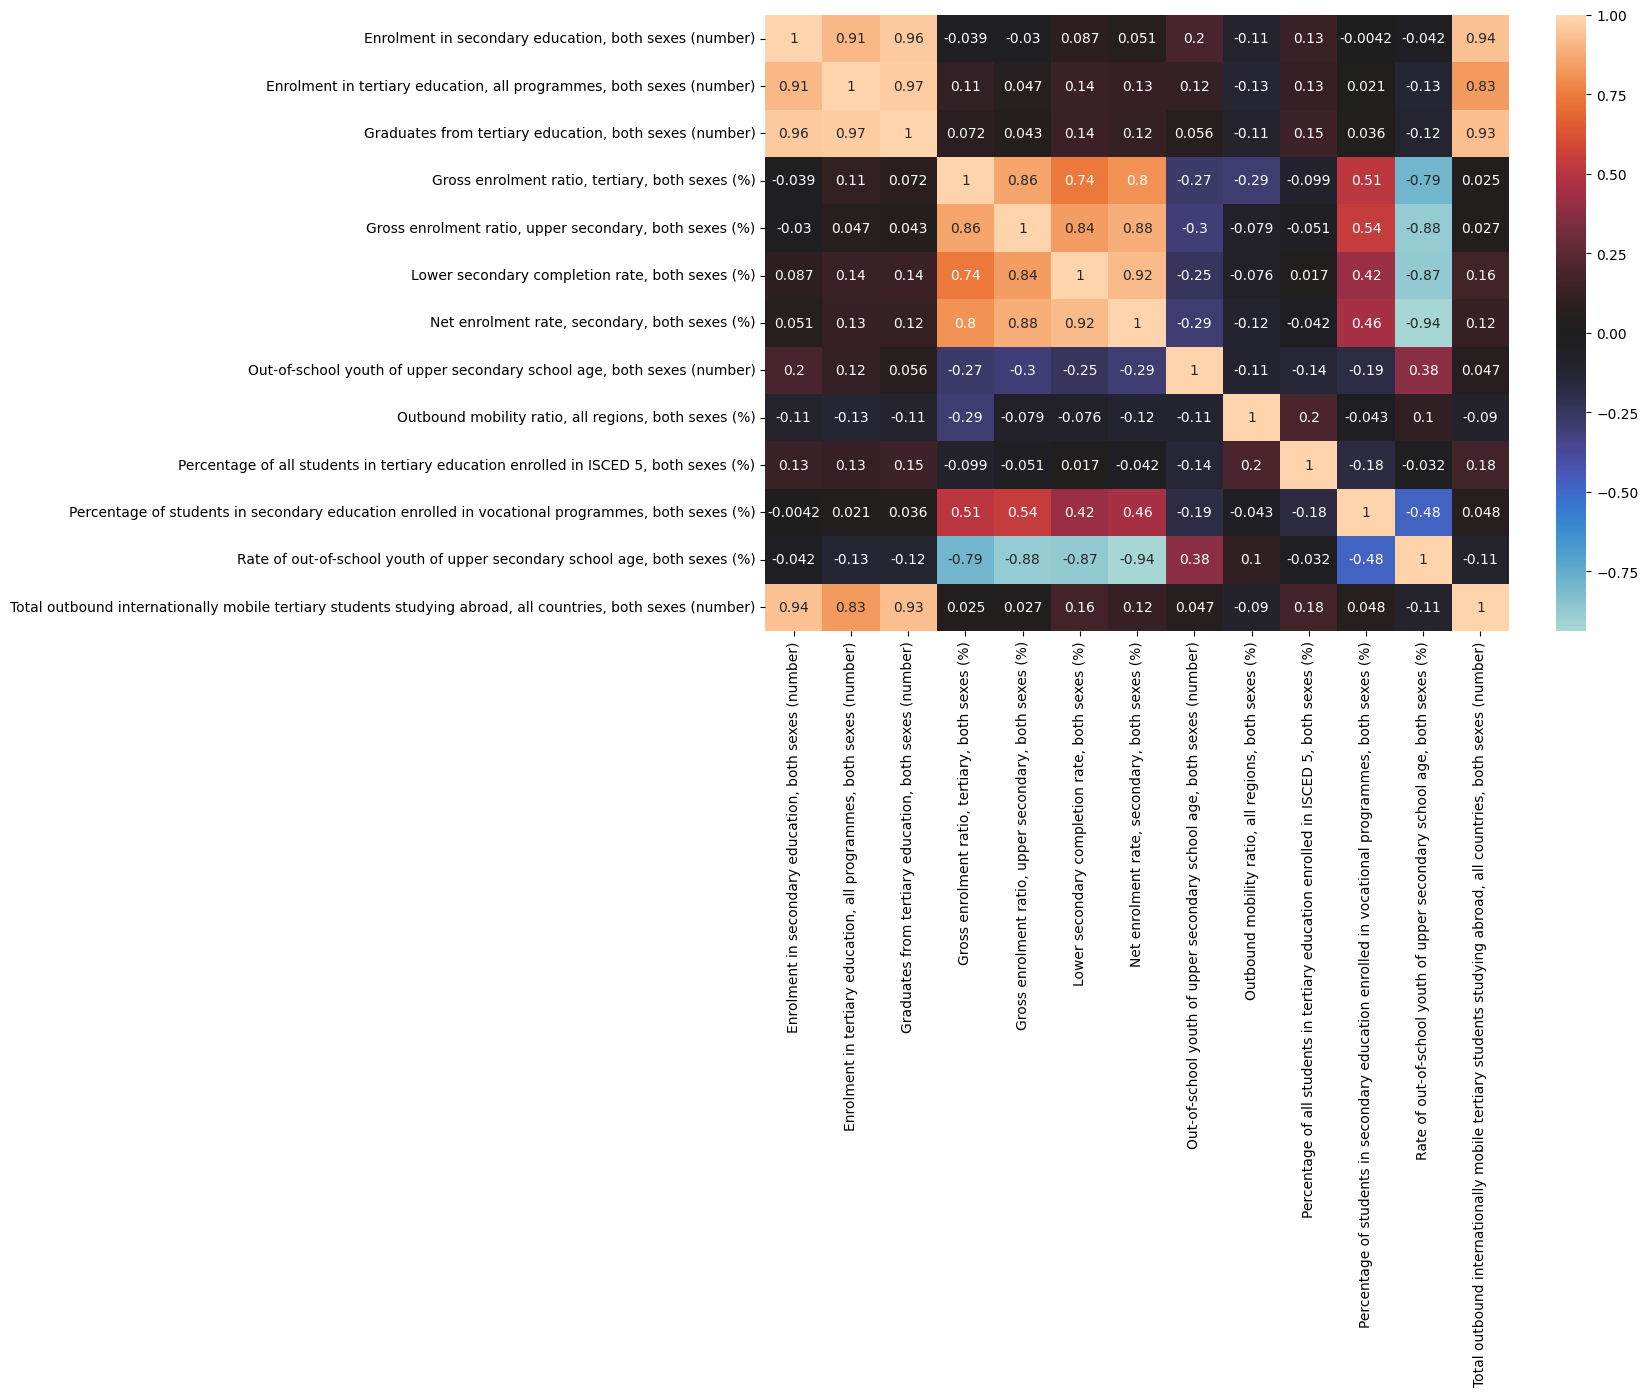

In [7]:
# pearson heatmap
plt.figure(figsize=(12,8))
sns.heatmap(pearson, annot= True, center = 0)
plt.show()

In [8]:
# creer les valuers absolues des indicateurs
spearman_abs = spearman.abs()

# Creer un mask pour choisir le triangle superiour
mask = np.triu(np.ones(spearman_abs.shape), k = 1).astype(bool)
upper_triang = spearman_abs.where(mask)

In [9]:
upper_triang

,"Enrolment in secondary education, both sexes (number)","Enrolment in tertiary education, all programmes, both sexes (number)","Graduates from tertiary education, both sexes (number)","Gross enrolment ratio, tertiary, both sexes (%)","Gross enrolment ratio, upper secondary, both sexes (%)","Lower secondary completion rate, both sexes (%)","Net enrolment rate, secondary, both sexes (%)","Out-of-school youth of upper secondary school age, both sexes (number)","Outbound mobility ratio, all regions, both sexes (%)","Percentage of all students in tertiary education enrolled in ISCED 5, both sexes (%)","Percentage of students in secondary education enrolled in vocational programmes, both sexes (%)","Rate of out-of-school youth of upper secondary school age, both sexes (%)","Total outbound internationally mobile tertiary students studying abroad, all countries, both sexes (number)"
"Enrolment in secondary education, both sexes (number)",NaN,0.925892,0.872425,0.133862,0.002446,0.058603,0.059863,0.714247,0.728561,0.111745,0.157704,0.004143,0.731962
"Enrolment in tertiary education, all programmes, both sexes (number)",NaN,NaN,0.945610,0.424836,0.262320,0.171118,0.287675,0.508259,0.801724,0.136856,0.299161,0.257796,0.784144
"Graduates from tertiary education, both sexes (number)",NaN,NaN,NaN,0.424892,0.299050,0.196541,0.330556,0.439499,0.723321,0.099699,0.290649,0.283105,0.777564
"Gross enrolment ratio, tertiary, both sexes (%)",NaN,NaN,NaN,NaN,0.865471,0.718395,0.821717,0.392612,0.408544,0.088654,0.570613,0.822951,0.342647
"Gross enrolment ratio, upper secondary, both sexes (%)",NaN,NaN,NaN,NaN,NaN,0.814887,0.918533,0.579199,0.194783,0.024935,0.556425,0.918836,0.284172
"Lower secondary completion rate, both sexes (%)",NaN,NaN,NaN,NaN,NaN,NaN,0.825939,0.566110,0.073515,0.069364,0.448805,0.788126,0.278629
"Net enrolment rate, secondary, both sexes (%)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.538946,0.181406,0.016632,0.519033,0.913884,0.360032
"Out-of-school youth of upper secondary school age, both sexes (number)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.415258,0.105971,0.192324,0.594696,0.361550
"Outbound mobility ratio, all regions, both sexes (%)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.164173,0.290904,0.226103,0.324771
"Percentage of all students in tertiary education enrolled in ISCED 5, both sexes (%)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.150285,0.056115,0.070745


In [10]:
# Selectionner les indicateurs redondants
to_drop = [col for col in upper_triang.columns if any(upper_triang[col] > 0.7)]

In [11]:
to_drop

['Enrolment in tertiary education, all programmes, both sexes (number)',
 'Graduates from tertiary education, both sexes (number)',
 'Gross enrolment ratio, upper secondary, both sexes (%)',
 'Lower secondary completion rate, both sexes (%)',
 'Net enrolment rate, secondary, both sexes (%)',
 'Out-of-school youth of upper secondary school age, both sexes (number)',
 'Outbound mobility ratio, all regions, both sexes (%)',
 'Rate of out-of-school youth of upper secondary school age, both sexes (%)',
 'Total outbound internationally mobile tertiary students studying abroad, all countries, both sexes (number)']

In [12]:
# Enlever les indicateurs redondants
final_df = df.drop(columns = to_drop)

In [13]:
final_df

,"Enrolment in secondary education, both sexes (number)","Gross enrolment ratio, tertiary, both sexes (%)","Percentage of all students in tertiary education enrolled in ISCED 5, both sexes (%)","Percentage of students in secondary education enrolled in vocational programmes, both sexes (%)"
Country Name,,,,
Albania,3.762216e+05,33.931094,1.232904,5.976005
Argentina,4.058737e+06,68.846463,28.938100,12.353627
Armenia,3.287558e+05,41.949221,19.905299,4.459767
Aruba,7.186077e+03,30.135898,66.114070,16.498523
Australia,2.383824e+06,76.502040,17.546985,37.257383
...,...,...,...,...
United Kingdom,5.541159e+06,58.954296,22.539829,18.960337
United States,2.404698e+07,84.056566,24.061673,12.353627
Uruguay,3.122505e+05,50.171839,17.277847,16.614207


In [14]:
# Une fonction pour les stats descriptives 

def describe(dataframe):
    for col in dataframe.columns:
        print(f"C'est les stats descriptives de {col}")
        print(dataframe[col].describe())
        plt.figure(figsize=(12,8))
        sns.displot(dataframe[col])
        plt.show()

C'est les stats descriptives de Enrolment in secondary education, both sexes (number)
count    1.090000e+02
mean     2.939881e+06
std      9.781920e+06
min      3.238182e+03
25%      2.958284e+05
50%      6.289108e+05
75%      2.194613e+06
max      9.491615e+07
Name: Enrolment in secondary education, both sexes (number), dtype: float64


<Figure size 1200x800 with 0 Axes>

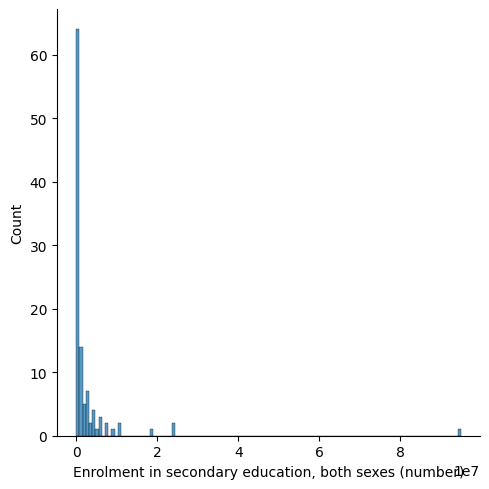

C'est les stats descriptives de Gross enrolment ratio, tertiary, both sexes (%)
count    109.000000
mean      38.174026
std       24.601504
min        0.493619
25%       13.940094
50%       37.305488
75%       58.954296
max       90.487108
Name: Gross enrolment ratio, tertiary, both sexes (%), dtype: float64


<Figure size 1200x800 with 0 Axes>

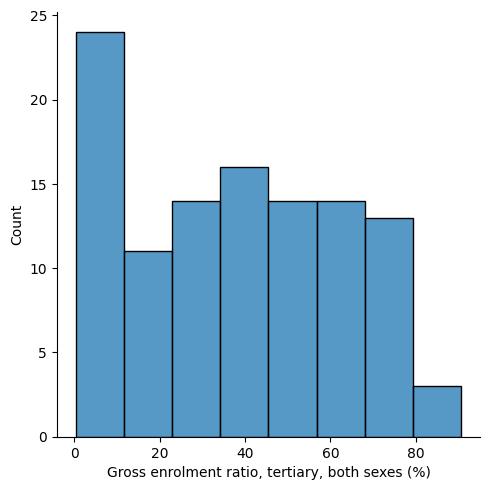

C'est les stats descriptives de Percentage of all students in tertiary education enrolled in ISCED 5, both sexes (%)
count    109.000000
mean      19.253132
std       13.712917
min        0.630683
25%        8.776225
50%       16.688365
75%       28.592587
max       66.114070
Name: Percentage of all students in tertiary education enrolled in ISCED 5, both sexes (%), dtype: float64


<Figure size 1200x800 with 0 Axes>

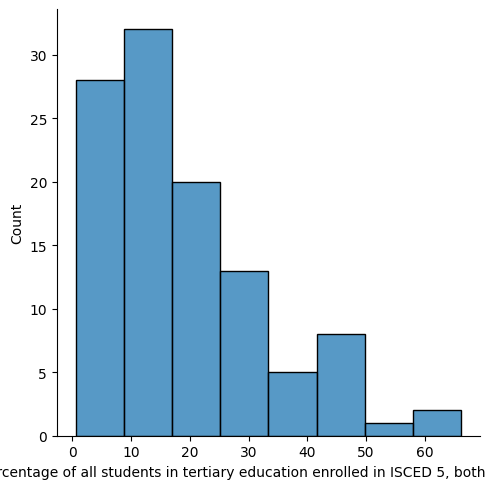

C'est les stats descriptives de Percentage of students in secondary education enrolled in vocational programmes, both sexes (%)
count    109.000000
mean      14.918094
std       12.578668
min        0.000000
25%        4.162425
50%       12.353627
75%       21.440503
max       59.623719
Name: Percentage of students in secondary education enrolled in vocational programmes, both sexes (%), dtype: float64


<Figure size 1200x800 with 0 Axes>

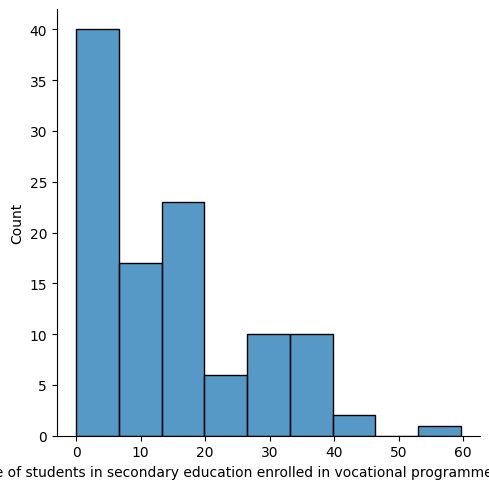

In [15]:
describe(final_df)

In [16]:
# Normaliser l'indicateur numerique en utlisant la methode min- max pour pouvoir creer les moyennes pondorees 
minimum = final_df["Enrolment in secondary education, both sexes (number)"].min()
maximum = final_df["Enrolment in secondary education, both sexes (number)"].max()
diff = maximum - minimum

final_df["scaled_secondary_enrolment"] = 100 * (final_df["Enrolment in secondary education, both sexes (number)"] - minimum) / diff

In [17]:
final_df  = final_df.drop(columns = "Enrolment in secondary education, both sexes (number)")

In [18]:
# creer un score final avec les moyennes ponderees
final_df["score"] = (
    final_df["scaled_secondary_enrolment"] * 0.4 +
    final_df["Gross enrolment ratio, tertiary, both sexes (%)"] * 0.4 +
    final_df["Percentage of all students in tertiary education enrolled in ISCED 5, both sexes (%)"] * 0.1 +
    final_df["Percentage of students in secondary education enrolled in vocational programmes, both sexes (%)"] * 0.1
)

In [19]:
# creer un score final avec les moyennes ponderees
top_five = list(final_df["score"].sort_values(ascending = False).head(5).index)

In [20]:
top_five

['China', 'United States', 'Greece', 'Finland', 'Slovenia']